### Chuẩn bị thư viện cần thiết

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

### Chuẩn bị dữ liệu

In [19]:
# Lấy về dữ liệu train và test
url_train = "/content/train.parquet"
url_test = "/content/test.parquet"

data_train = pd.read_parquet(url_train)
data_test = pd.read_parquet(url_test)

### Xử lý benchmark

In [20]:
def build_request_rate(df, window):
    df_raw = df.copy()

    rate_df = (
        df_raw
        .set_index("timestamp")
        .resample(window)
        .size()
        .rename("request_rate")
        .reset_index()
    )

    return rate_df

### Ý tưởng xây dựng
Sử dụng kĩ thuật EMWA để học đường baseline (bao gồm trend, seasonality). Sau khi có đường baseline rút ra residual từ công thức:
$$
    y_{residual} = y - y_{baseline}
$$
Residual sẽ do LightGBM học

### Model baseline từ thống kê EMWA

In [21]:
def build_baseline(rate_df):
    df = rate_df.sort_values("timestamp").reset_index(drop=True)
    y = df["request_rate"]

    # EWMA slow (long memory)
    df["ewma_slow"] = y.shift(1).ewm(alpha=0.02, adjust=False).mean()

    # EWMA fast (medium memory)
    df["ewma_fast"] = y.shift(1).ewm(alpha=0.15, adjust=False).mean()

    # Combined baseline
    df["baseline"] = 0.7 * df["ewma_slow"] + 0.3 * df["ewma_fast"]

    # Residual
    df["residual"] = y - df["baseline"]

    return df


### Dự đoán residual

In [22]:
def build_feature(rate_df):
    df = build_baseline(rate_df)
    r = df["residual"]

    # Short-term memory only
    lags = [1, 2, 3, 5]
    for lag in lags:
        df[f"lag_{lag}"] = r.shift(lag)

    # Volatility & local range
    for win in [3, 5]:
        df[f"roll_std_{win}"] = r.shift(1).rolling(win).std()
        df[f"roll_max_{win}"] = r.shift(1).rolling(win).max()
        df[f"roll_min_{win}"] = r.shift(1).rolling(win).min()

    # Burst dynamics
    df["diff_1"] = r.shift(1) - r.shift(2)
    df["diff_2"] = r.shift(1) - r.shift(3)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=[
        "timestamp",
        "request_rate",
        "baseline",
        "residual"
    ])

    y = df["residual"]

    return X, y, df


In [23]:
def build_model(dtrain, dtest):
    model = lgb.LGBMRegressor(
        objective="regression",
        learning_rate=0.02,
        num_leaves=63,
        max_depth=7,
        min_data_in_leaf=100,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        lambda_l2=5,
        n_estimators=300,
        random_state=42
    )
    model.fit(dtrain, dtest)
    return model

In [24]:
def evaluate(y_true, y_pred, eps=1e-8, as_table=True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = np.abs(y_true) > eps

    metrics = {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": (
            mean_absolute_percentage_error(y_true[mask], y_pred[mask])
            if mask.any() else np.nan
        )
    }

    if as_table:
        return pd.DataFrame(
            metrics.values(),
            index=metrics.keys(),
            columns=["Value"]
        )

    return metrics

### Feature Importance

In [25]:
def feature_importance(model):
    return lgb.plot_importance(model, xlabel='importance', ylabel='Features')

In [26]:
def plot_timeseries(
    df_test,
    X_test,
    model,
    baseline_col="baseline",
    target_col="request_rate",
    time_col="timestamp",
    figsize=(14, 3)
    ):

    # ============================
    # Chuẩn bị dữ liệu
    # ============================
    ts = df_test[time_col].values
    y_true = df_test[target_col].values
    baseline_pred = df_test[baseline_col].values

    residual_true = y_true - baseline_pred
    residual_pred = model.predict(X_test)

    y_pred = baseline_pred + residual_pred

    # ============================
    # Biểu đồ 1: Residual
    # ============================
    plt.figure(figsize=figsize)
    plt.plot(ts, residual_true, label="Residual actual")
    plt.plot(ts, residual_pred, label="Residual predicted")
    plt.legend()
    plt.title("Residual: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

    # ============================
    # Biểu đồ 2: Baseline
    # ============================
    plt.figure(figsize=figsize)
    plt.plot(ts, y_true, label="Actual")
    plt.plot(ts, baseline_pred, label="Baseline prediction")
    plt.legend()
    plt.title("Baseline vs Actual")
    plt.xlabel("Time")
    plt.ylabel("Request rate")
    plt.tight_layout()
    plt.show()

    # ============================
    # Biểu đồ 3: Tổng
    # ============================
    plt.figure(figsize=figsize)
    plt.plot(ts, y_true, label="Actual")
    plt.plot(ts, y_pred, label="Final prediction")
    plt.legend()
    plt.title("Final Prediction vs Actual")
    plt.xlabel("Time")
    plt.ylabel("Request rate")
    plt.tight_layout()
    plt.show()

### Pipeline thực thi

In [27]:
def pipeline_impl(raw_train, raw_test, w):

    # Chuyển dữ liệu về request
    WINDOW = w
    rate_df_train = build_request_rate(data_train, WINDOW)
    rate_df_test = build_request_rate(data_test, WINDOW)

    # Học residual
    X_train, y_train, df_train = build_feature(rate_df_train)
    X_test,  y_test,  df_test  = build_feature(rate_df_test)

    # Huấn luyện model
    lgbm = build_model(X_train, y_train)

    # Tái lập công thức: y_pred = y_residual + y_baseline
    residual_pred = lgbm.predict(X_test)
    y_pred = df_test["baseline"].values + residual_pred
    y_true = df_test["request_rate"].values

    # Đánh giá model
    df_metrics = evaluate(y_true, y_pred,as_table = True)
    print(df_metrics.head())
    # Feature importance
    feature_importance(lgbm)

    # Vẽ model
    plot_timeseries(df_test=df_test,
                    X_test=X_test,
                    model=lgbm)


### Benchmark 1m

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored

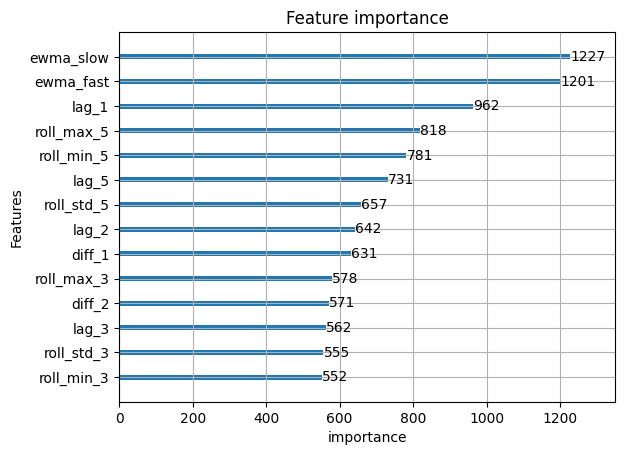

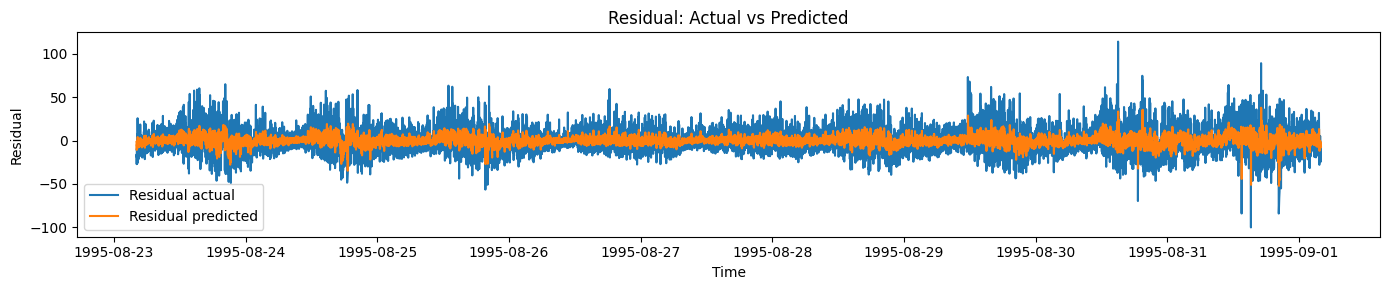

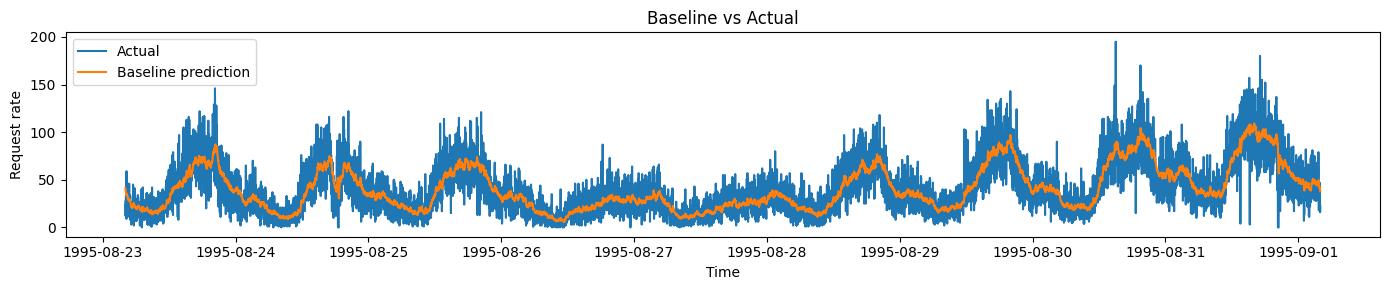

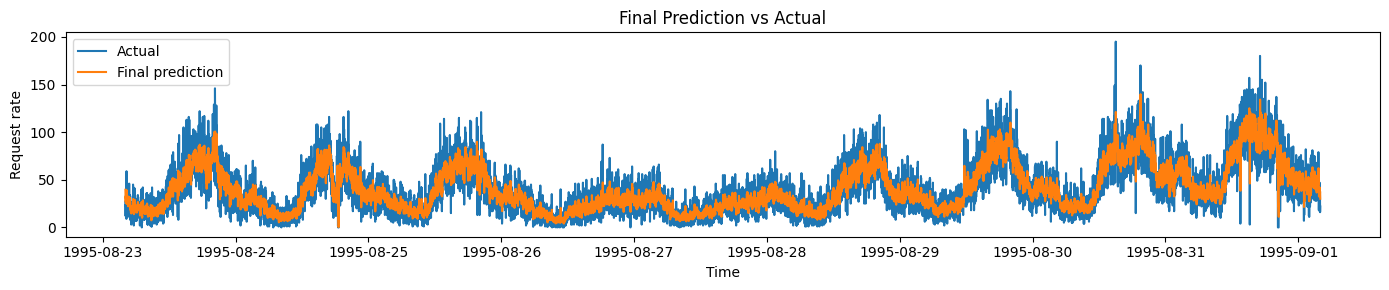

In [28]:
pipeline_impl(data_train, data_test, '1min')

### Benchmark 5m

/tmp/ipython-input-1061874067.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample(window)
/tmp/ipython-input-1061874067.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample(window)


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored

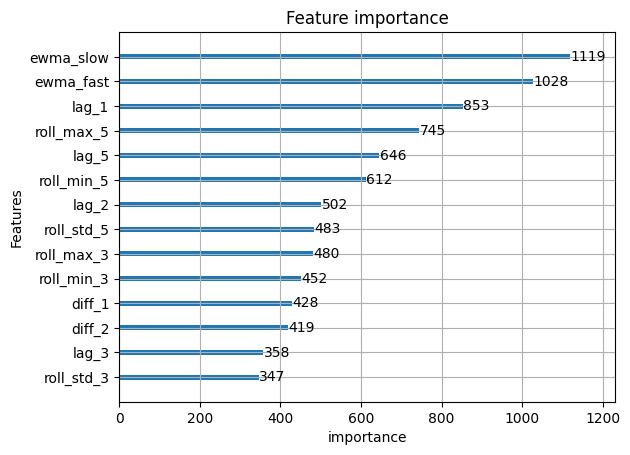

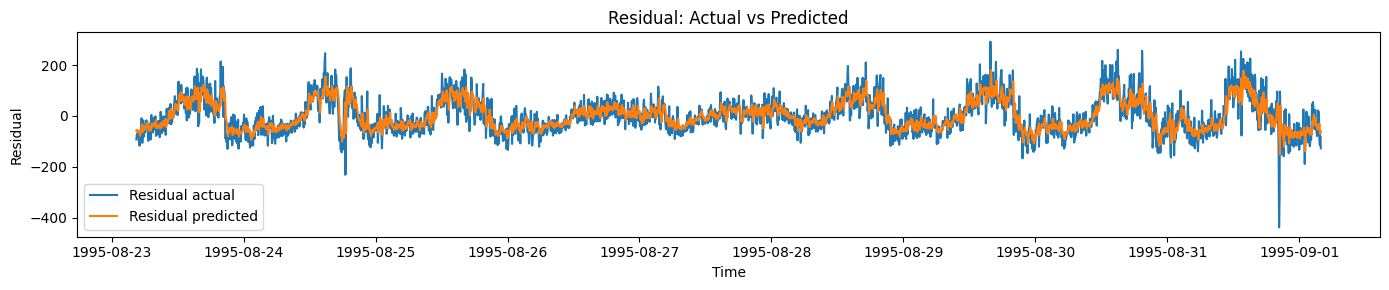

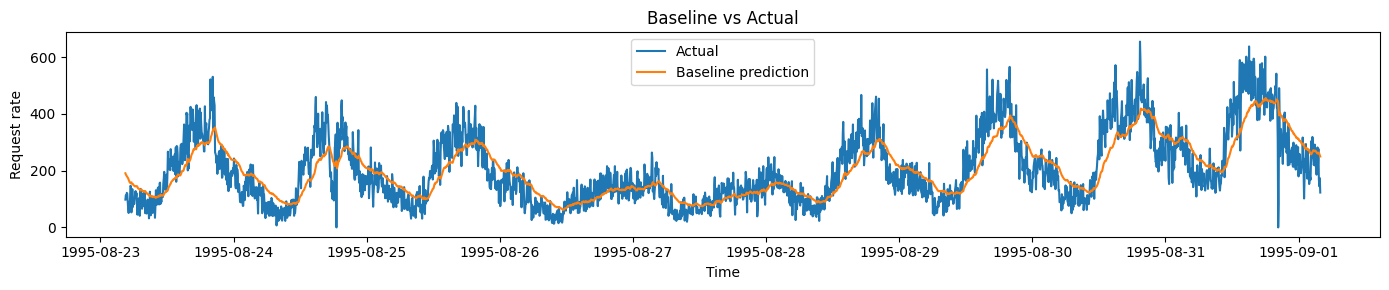

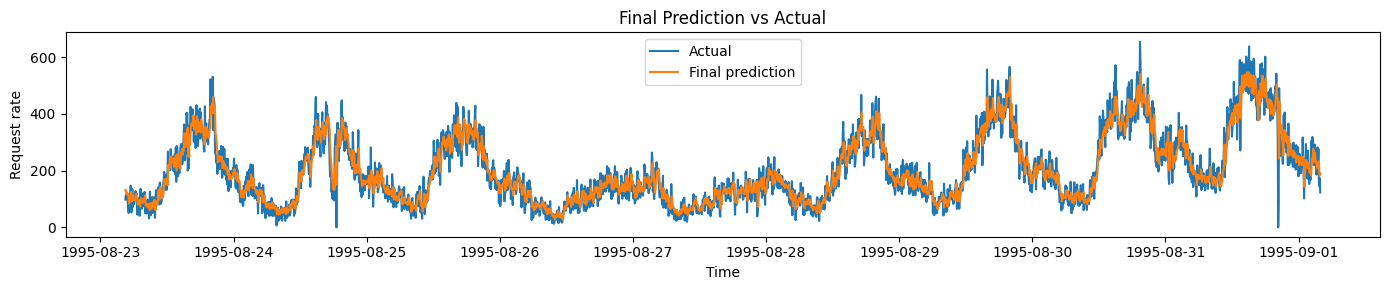

In [29]:
pipeline_impl(data_train, data_test, '5T')

### Benchmark 15m

/tmp/ipython-input-1061874067.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample(window)
/tmp/ipython-input-1061874067.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample(window)


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored

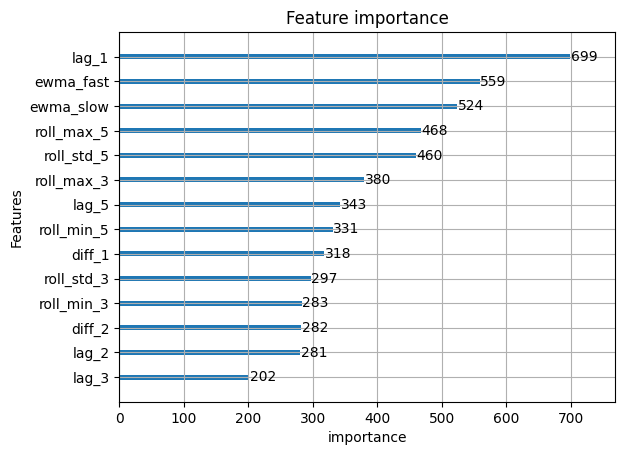

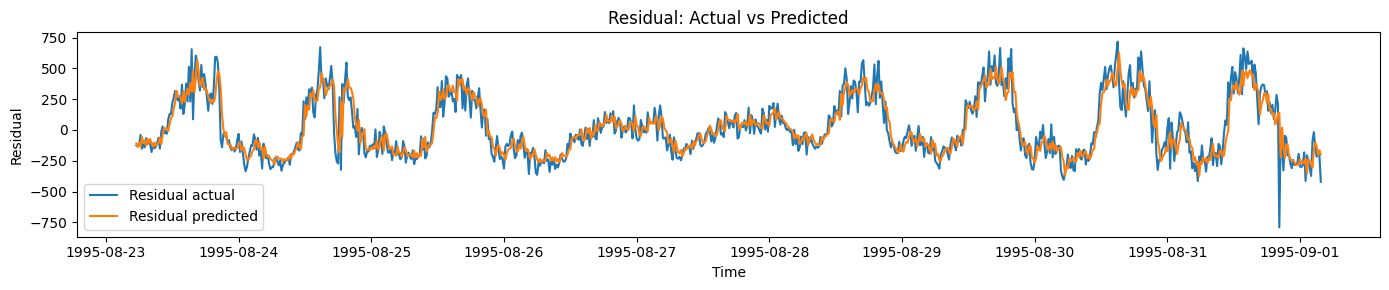

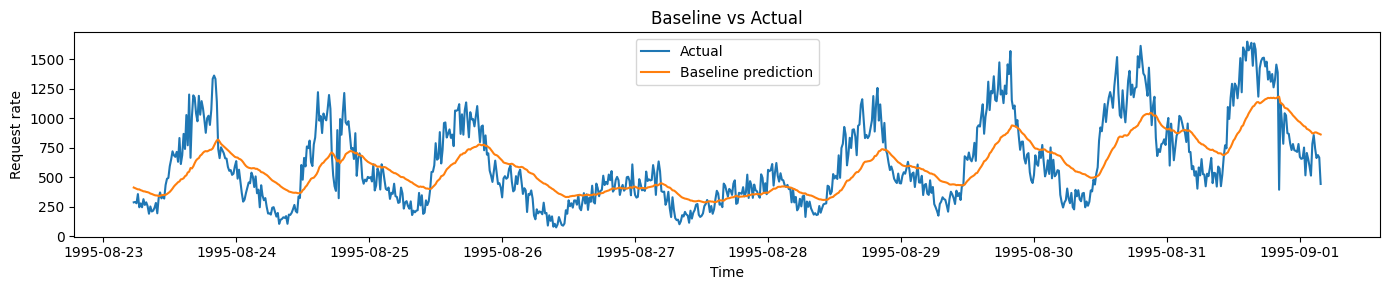

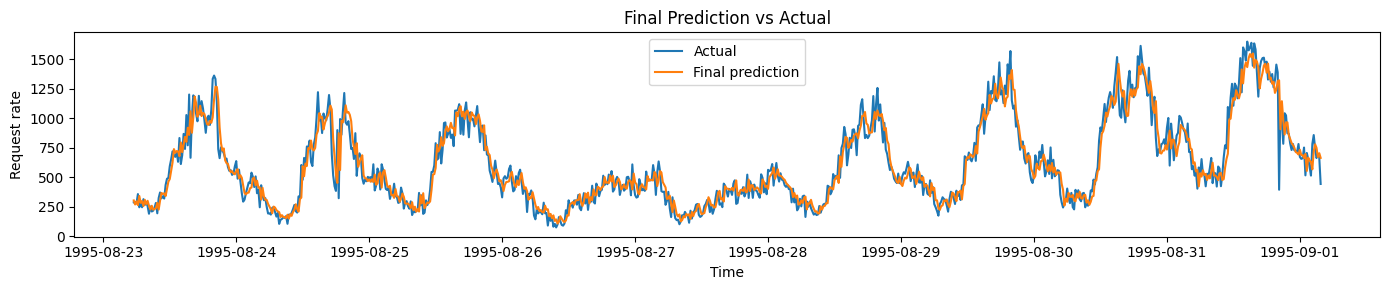

In [30]:
pipeline_impl(data_train, data_test, '15T')